In [1]:
import numpy as np
import pandas as pd
import jax

import matplotlib.pyplot as plt

from bilby.gw.conversion import lambda_1_lambda_2_to_lambda_tilde, lambda_1_lambda_2_to_delta_lambda_tilde, lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2

from jesterTOV.inference.population.populations import MassRatioPowerLaw

In [5]:
wide_df = pd.read_csv("../../events/gw/gw_params_wide.dat", sep=" ")
detection_df = pd.read_csv("../../events/detection/detection_output/wide_ETL.dat", sep=" ")
events = pd.read_csv("events.dat", sep=" ")
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

narrow_etl = pd.read_csv("../narrow_ETL/events.dat", sep=" ")
wide_ett = pd.read_csv("../wide_ETT/events.dat", sep=" ")
narrow_ett = pd.read_csv("../narrow_ETT/events.dat", sep=" ")


In [8]:
np.argsort(narrow_etl["snr"])

0     34
1     11
2     55
3     43
4      1
      ..
73    42
74    25
75    73
76    74
77    64
Name: snr, Length: 78, dtype: int64

In [7]:
np.argsort(narrow_ett["snr"])

0     37
1     40
2     25
3     31
4     32
5     19
6      9
7     24
8     23
9     33
10    35
11    20
12    27
13    13
14     4
15     0
16    10
17     7
18     6
19    41
20    18
21    11
22     3
23    43
24    12
25    15
26    30
27    26
28     5
29    21
30    42
31    34
32     2
33     1
34    16
35    45
36    38
37    36
38    17
39    22
40    14
41    29
42     8
43    28
44    44
45    39
Name: snr, dtype: int64

In [3]:
np.sort(events["snr"])

array([ 12.688,  17.359,  19.175,  20.064,  21.24 ,  21.694,  24.028,
        25.087,  25.444,  25.471,  26.636,  28.168,  29.205,  29.282,
        30.797,  31.043,  31.405,  31.889,  32.621,  32.88 ,  33.058,
        35.473,  37.445,  37.969,  40.926,  42.032,  44.473,  50.366,
        50.593,  52.768,  56.032,  62.02 ,  83.775,  90.322, 118.255,
       123.374, 162.01 , 187.705, 326.698])

In [4]:
np.sort(wide_ett["snr"])

array([ 12.873,  13.97 ,  15.215,  15.562,  15.602,  17.442,  18.353,
        19.491,  19.566,  20.022,  20.235,  22.02 ,  22.313,  22.405,
        22.739,  25.315,  25.864,  26.259,  27.02 ,  28.971,  29.978,
        30.769,  33.935,  38.708,  58.396,  89.645, 105.778, 235.961])

(array([6., 3., 6., 8., 6., 2., 1., 2., 2., 3.]),
 array([1.2147153 , 1.28973318, 1.36475106, 1.43976894, 1.51478682,
        1.5898047 , 1.66482258, 1.73984047, 1.81485835, 1.88987623,
        1.96489411]),
 [<matplotlib.patches.Polygon at 0x7f83c531b490>])

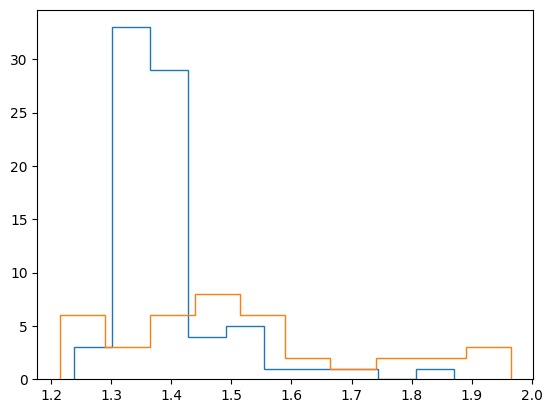

In [21]:
plt.hist(narrow_etl["mass_1_source"], histtype="step")
plt.hist(events["mass_1_source"], histtype="step")

(array([2., 2., 3., 4., 1., 5., 6., 8., 3., 5.]),
 array([0.5829771 , 0.62435014, 0.66572317, 0.70709621, 0.74846925,
        0.78984229, 0.83121533, 0.87258837, 0.9139614 , 0.95533444,
        0.99670748]),
 [<matplotlib.patches.Polygon at 0x7f83ccf979d0>])

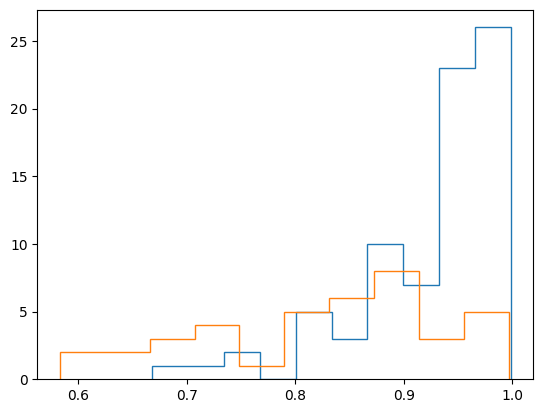

In [13]:
plt.hist(narrow_etl["mass_2_source"] / narrow_etl["mass_1_source"], histtype="step")
plt.hist(events["mass_2_source"] / events["mass_1_source"], histtype="step")

In [22]:
np.max(events["mass_1_source"])

np.float64(1.9648941076709967)

In [3]:
n_coll = np.sum(events["prompt_collapse"] ==1 )
n_tot = events.shape[0]
pop_coll_share = np.sum(wide_df["prompt_collapse"]==1)/wide_df.shape[0]

print(f"Prompt collapse: {n_coll}/{n_tot}, {n_coll/n_tot:.3f}, ", pop_coll_share)

Prompt collapse: 9/39, 0.231,  0.7548668655397194


In [13]:
events["redshift_measured"] = events_old["redshift_measured"]
events.to_csv("events.dat", sep=" ")

In [4]:
log10_mej_wind = events["log10_mej_wind"]
zeta = 10**(events["log10_mej_wind"] - events["log10_mdisk"])

print("wind quantile: ", np.quantile(log10_mej_wind, 0.05))
print("zeta quantile: ", np.quantile(zeta, 0.05))

wind quantile:  -2.132894045168035
zeta quantile:  0.15505655615759853


In [5]:
print("SNR min max: ", np.min(events["snr"]), np.max(events["snr"]))

SNR min max:  15.055 229.002


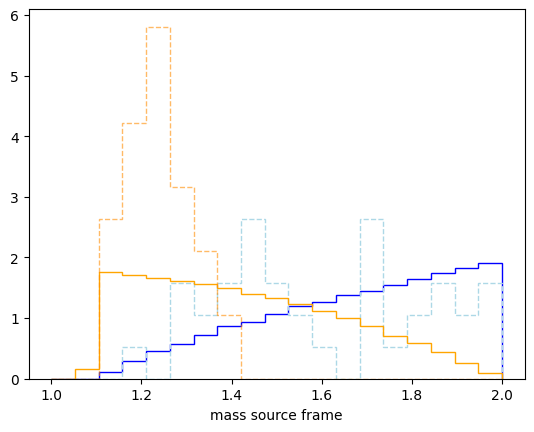

In [6]:
bins = np.linspace(1, 2, 20)

plt.hist(wide_df["mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(events.loc[:, "mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(wide_df["mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(events.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")


plt.xlabel("mass source frame")
plt.show()

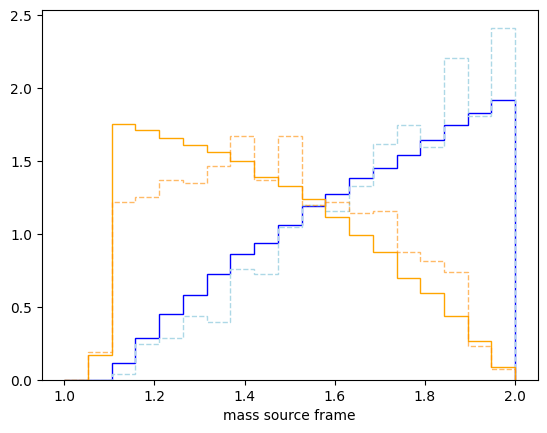

In [7]:
bins = np.linspace(1, 2, 20)


plt.hist(wide_df.loc[:, "mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(wide_df.loc[detection_df["gw_detected"].astype(bool), "mass_1_source"][:1000], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(wide_df.loc[:, "mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(wide_df.loc[detection_df["gw_detected"].astype(bool), "mass_2_source"][:1000], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")



plt.xlabel("mass source frame")
plt.show()

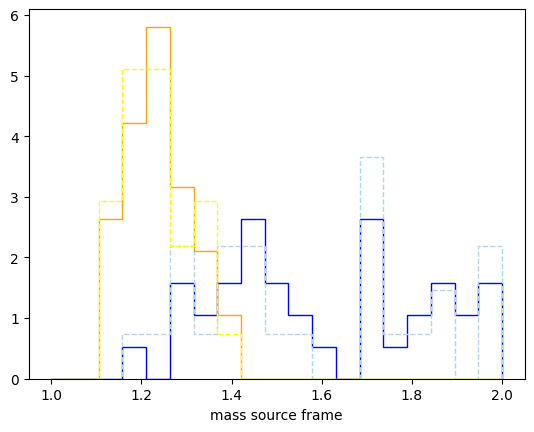

In [6]:
bins = np.linspace(1, 2, 20)

plt.hist(events.loc[:, "mass_1_source"], bins=bins, density=True, histtype="step", color="blue", linestyle="solid")
plt.hist(events_ett.loc[:, "mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(events.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", color="orange", linestyle="solid")
plt.hist(events_ett.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", color="yellow", linestyle="dashed")

plt.xlabel("mass source frame")
plt.show()

In [10]:
events_ett.loc[~np.isin(events_ett["redshift"], events["redshift"])]

,Unnamed: 0,redshift,luminosity_distance,mass_1_source,mass_2_source,chi_eff,chi_1,chi_2,mass_1,mass_2,...,prompt_collapse.1,has_grb,thetaCore,log10_Ekin_iso,log10_n0,afterglow_detected,snr,chirp_mass,mass_ratio,redshift_measured
2,2,0.465974,2685.277020,1.391419,1.284132,0.045037,-0.017068,0.112331,2.039784,1.882504,...,3,False,0.102750,51.897418,-3.173434,False,12.084,1.705628,0.922894,0.463388
11,11,0.148694,730.027377,1.227770,1.186133,-0.045732,-0.027770,-0.064324,1.410332,1.362504,...,4,False,0.405641,50.215997,-4.261281,True,25.334,1.206731,0.966087,0.147290
19,19,0.349889,1915.750215,1.394799,1.248588,-0.048601,-0.074007,-0.020220,1.882824,1.685455,...,3,False,0.053617,52.665759,-3.537473,False,16.104,1.550331,0.895174,0.352454
21,21,0.337323,1835.899411,1.961361,1.370000,0.089496,0.115680,0.052011,2.622973,1.832132,...,1,True,0.096414,52.119617,-1.276422,True,15.215,1.902299,0.698494,0.336495


In [8]:
events_ett[["redshift", "mass_2_source", "snr"]]

,redshift,mass_2_source,snr
0,0.090983,1.334893,104.914
1,0.369232,1.340060,15.915
2,0.465974,1.284132,12.084
3,0.228727,1.213491,27.835
4,0.135612,1.209442,20.235
5,0.434613,1.222484,31.598
6,0.101763,1.339704,44.794
7,0.262437,1.155561,22.496
8,0.271821,1.190876,19.243
9,0.144014,1.173076,26.781


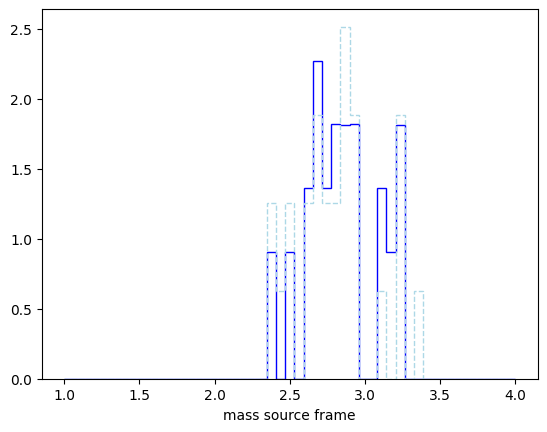

In [11]:
bins = np.linspace(1, 4, 50)

plt.hist(events.loc[:, "mass_1_source"] + events.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", color="blue", linestyle="solid")
plt.hist(events_ett.loc[:, "mass_1_source"] + events_ett.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.xlabel("mass source frame")
plt.show()

In [12]:
np.mean(events.loc[:, "mass_1_source"] + events.loc[:, "mass_2_source"])

np.float64(2.844423439086224)

In [13]:
np.mean(events_ett.loc[:, "mass_1_source"] + events_ett.loc[:, "mass_2_source"])

np.float64(2.8111095274712645)

In [18]:
np.sort(events["mass_2_source"])

array([1.11347743, 1.11862252, 1.12835887, 1.15373059, 1.15556114,
       1.17307589, 1.17855012, 1.18853798, 1.19087599, 1.19619385,
       1.19723714, 1.20463063, 1.20944164, 1.2134905 , 1.222484  ,
       1.23011606, 1.24405758, 1.2495077 , 1.25070992, 1.25250092,
       1.25487252, 1.25560689, 1.25879191, 1.25927376, 1.28553234,
       1.2863292 , 1.28837239, 1.3080987 , 1.31277012, 1.31511497,
       1.33489306, 1.33970378, 1.34006034, 1.36823817, 1.37725519,
       1.38420436])

In [19]:
np.sort(events_ett["mass_2_source"])

array([1.11347743, 1.12835887, 1.15373059, 1.15556114, 1.17307589,
       1.17855012, 1.18613276, 1.18853798, 1.19087599, 1.19723714,
       1.20944164, 1.2134905 , 1.222484  , 1.23011606, 1.24858769,
       1.25070992, 1.25250092, 1.25927376, 1.28413243, 1.28553234,
       1.28837239, 1.33489306, 1.33970378, 1.34006034, 1.36823817,
       1.36999977])